# NB05 — Backtest: Ablation of Three Strategies

**Question:** Does the LLM-augmented event-study model translate its CAR-sign edge (NB04) into a tradable, risk-adjusted return advantage over a tech-only comparator and a passive benchmark?

## Pipeline

```
NB00 sessions/prices ──▶ NB02 llm_signals ──▶ NB03 car_labels ──▶ NB04 event_study_best.pkl
                                                                              │
NB05 (this notebook):  pkl + sessions + prices + llm_signals + car_labels ────┘
   1. Load              — NB04 best model (rf + Optuna params), price panel, CAR labels
   2. Predict           — arm C: predict_proba from pkl;  arm B: refit same arch on tech+sector only (train+val)
   3. Trade rule        — selection, weighting, holding window, anti-leakage guarantees
   4. Thresholds        — top/bottom 20% quintiles of p on val 2023, frozen for test
   5. Event → daily PnL — open at event+ENTRY_OFFSET, hold HOLDING_DAYS, equal-weight overlapping positions
   6. Curves + metrics  — cumulative returns + Sharpe / ann. return / vol / MDD / IR vs SPY
   8. Significance      — Newey-West t (lag=5) per arm + paired ES−Tech, Memmel z + block bootstrap CI
   9. Event-level tests — Spearman ρ + Mann-Whitney U on CAR_2_21 (power-friendlier than daily-PnL)
  10. Permutation imp.  — OOS Δ AUC by feature/block (Tech / Sector / LLM), pooled + per year
  11. Feature ablation  — refit-based block ablation + drop-one LLM (val AUC, complements §10)
  12. Conclusion        — six layers of evidence, what the data does and does not support
  13. Limitations       — sample size, cost, prompt design, RAG ceiling
```

## Ablation arms (strategies)

| Arm | Features | Purpose |
|-----|----------|---------|
| **A · BuyHold_EW50** | none (passive equal-weight 50 names) | Passive floor — the bar to clear |
| **B · Tech-only** | tech (5) + sector one-hot (11) | Fair comparator — same model, LLM features removed |
| **C · Event-Study (LLM+Tech)** | tech + sector + LLM (6) | Full feature set — main candidate |

**B vs C** isolates LLM-signal alpha (same algorithm, same Optuna hyperparams, only the 6 LLM features differ).

In [ ]:
import sys, warnings, joblib
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

import config
from llm_agent.data_loader import load_sessions, load_prices, load_llm_signals, split_by_period
from llm_agent.features import build_feature_matrix, feature_columns # have already defined as functions in 04_ml_models.ipynb
from llm_agent.models import predict_proba_safe # have already defined as functions in 04_ml_models.ipynb
from llm_agent.metrics import compute_all_metrics

sns.set_style('whitegrid')
MAIN_WINDOW = 'car_2_11'
# Trade-execution params picked by val-2023 grid search (entry × hold × weighting)
ENTRY_OFFSET = 5      # open at event + 5 trading days (skip immediate reaction)
HOLDING_DAYS = 15     # hold 15 days (catch medium-term PEAD drift)
WEIGHTING    = 'prob' # 'equal' = ±1 fixed; 'prob' = 2*(p-0.5) capped to [-1, 1]


## 1. Load NB04 best model + base data

In [18]:
best = joblib.load(config.MODELS_DIR / 'event_study_best.pkl')
print(f'best model: {best["name"]}')
print(f'best params: {best["best_params"]}')

sessions = load_sessions()
prices = load_prices()
llm = load_llm_signals()
car = pd.read_parquet(config.CLEAN_DIR / 'car_labels.parquet')

# build daily price panel: date × ticker → adj_close return
px = prices.pivot_table(index='date', columns='ticker', values='adj_close').sort_index()
ret = px.pct_change()
trading_days = ret.index
print(f'panel: {ret.shape[0]} days × {ret.shape[1]} tickers')

best model: rf
best params: {'max_depth': 19, 'min_samples_leaf': 20, 'max_features': 0.8}
panel: 2150 days × 51 tickers


## 2. Build event-driven prediction frames for arms B (Tech) and C (LLM+Tech)

Arm C uses the saved tuned model directly (refit on train+val). Arm B refits the same architecture/params on the tech-only feature set.

In [21]:
def merged(arm):
    """ Build merged dataframe for arm B or C, with features + target."""
    X = build_feature_matrix(sessions, prices, llm, arm)
    cols = feature_columns(arm)
    df = X.merge(car[['session_id', MAIN_WINDOW]], on='session_id', how='inner')
    return df.dropna(subset=cols + [MAIN_WINDOW]).sort_values('event_date').reset_index(drop=True), cols


In [23]:
df_C, cols_C = merged('C')
df_B, cols_B = merged('B')
print(f'arm C: {len(df_C)} events with complete features and CAR labels')
print(f'arm B: {len(df_B)} events with complete features and CAR labels')

arm C: 1480 events with complete features and CAR labels
arm B: 1480 events with complete features and CAR labels


In [27]:
# Arm C: use saved best model (RF + Optuna params, refit on train+val in NB04) as-is
# predict_proba_safe function defined in src/llm_agent/models.py: 153

assert best['name'] == 'rf', f"NB05 assumes rf winner; got {best['name']}"
df_C['p'] = predict_proba_safe(best['model'], df_C[cols_C].values) # predict_proba_safe returns 0.5 if any error during prediction; otherwise returns predicted probability for class 1 (positive CAR)

# Arm B: same RF architecture + Optuna params, refit on tech-only features (train+val)
tech_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1)),
])
tech_pipe.set_params(**{f'clf__{k}': v for k, v in best['best_params'].items()})

df_B['y'] = (df_B[MAIN_WINDOW] > 0).astype(int)
trval_B = pd.concat([split_by_period(df_B, 'train'), split_by_period(df_B, 'val')], ignore_index=True)
tech_pipe.fit(trval_B[cols_B].values, trval_B['y'].values)
df_B['p'] = predict_proba_safe(tech_pipe, df_B[cols_B].values)

print(f"predicted probabilities: arm C (tech+LLM) vs. arm B (tech-only)")
print(df_C['p'].describe())
print(df_B['p'].describe())


predicted probabilities: arm C (tech+LLM) vs. arm B (tech-only)
count    1480.000000
mean        0.499260
std         0.090891
min         0.246438
25%         0.436070
50%         0.502981
75%         0.567721
max         0.739631
Name: p, dtype: float64
count    1480.000000
mean        0.512407
std         0.087610
min         0.241324
25%         0.450862
50%         0.518076
75%         0.576198
max         0.742264
Name: p, dtype: float64



## 3. Trade rule

Now, I'll explain our pipline first

### Step 1 — Score every event

Each earnings call yields one row in arm B's and arm C's prediction frame. The fitted RF outputs

```
p = P(CAR_2_11 > 0  |  features)   ∈ [0, 1]
```

i.e. the probability the 10-day excess-of-SPY CAR (NB03) is positive. Arm B and arm C produce **different `p` values for the same event** because they use different feature sets — that's exactly what the ablation is comparing.

### Step 2 — Thresholds (val-2023, frozen)

Within **each arm independently**, take its `p` distribution on the val-2023 subset and freeze the **top/bottom 20% quintiles** as trading thresholds:

```
p_long_thr  = quantile(p_val, 0.80)    # only events above this go long
p_short_thr = quantile(p_val, 0.20)    # only events below this go short
```

*Frozen* means the same two numbers are reused for test_2024 and test_2025 — no recalibration on test data. Arm B and arm C have **different** thresholds because their `p` distributions differ (arm B is slightly more bullish-biased: arm B mean ≈ 0.512 vs arm C mean ≈ 0.499 in the `.describe()` above).

20% (Fama-French quintile convention) is a deliberate trade-off: tighter (top decile) gives cleaner signal but ~30 trades/yr; looser (top tercile) dilutes the edge.

### Step 3 — Position weight per event

```
in_basket = (p ≥ p_long_thr) OR (p ≤ p_short_thr)
```

Events between the thresholds are **skipped** (no position). For events that pass:

| `WEIGHTING` | Formula | Notes |
|---|---|---|
| `'equal'` | `+1` if `p ≥ p_long_thr`, else `−1` | Direction-only — every selected event sized identically |
| `'prob'` | `clip(2·(p − 0.5), −1, +1)` | Confidence-scaled: `p = 0.9` → weight `+0.8`; `p = 0.6` → weight `+0.2` |

Default in this notebook: `WEIGHTING = 'prob'`. The thresholds **still gate entry** under `'prob'` — the clip only down-weights borderline trades, it does not introduce new ones.

### Step 4 — Holding window: `[event + ENTRY_OFFSET, event + ENTRY_OFFSET + HOLDING_DAYS)`

```
ENTRY_OFFSET = 5      # skip 5 trading days after the call before opening
HOLDING_DAYS = 15     # then hold for 15 trading days
```

Position opens on the **5th trading day** after the call (not day +2 as the labels use). Rationale: the +1/+2 day move is mostly the immediate reaction (overnight gap + day-of surge) and is largely priced in — the LLM signal's edge, if any, lies in the **post-earnings announcement drift** (PEAD), which empirically lasts ~2 weeks. Skipping the noisy reaction days isolates the drift component the model is actually predicting.

`HOLDING_DAYS = 15` is intentionally **longer than the label window** (`car_2_11`, 10 days): a 15-day hold lets a slowly-diffusing signal accumulate, and reduces turnover. Both `ENTRY_OFFSET` and `HOLDING_DAYS` were picked on a val-2023 grid (entry × hold × weighting) — never on test.

### Step 5 — Overlapping events → daily portfolio return

Many events overlap in calendar time (50 tickers × ~4 calls/yr × 15-day holds ≈ 200 events/yr, often 5–10 simultaneously open). The portfolio return on day `t` is the **simple mean** of all currently-open per-event PnLs:

```
r_portfolio(t) = mean over open events i of  weight_i · daily_return_{ticker_i, t}
```

Every open event gets the same *fractional* exposure regardless of how many overlap that day — gross exposure is always ≤ 1, so there is **no implicit leverage**. Days with zero open positions get `0` (cash-flat), not NaN, so they correctly drag down annual Sharpe rather than being silently dropped.

### Anti-leakage guarantees

- Thresholds picked only on val 2023, never recalibrated on test
- `ENTRY_OFFSET` / `HOLDING_DAYS` / `WEIGHTING` tuned only on val 2023
- Arm B refit on **train + val**, never on test (matches NB04's pkl protocol for arm C)
- Features for every event use prices strictly **before** `event_date` (`features._technicals_at_event` enforces `<`, not `<=`)
- test_2024 and test_2025 are scored independently and never combined for tuning
- Headline run uses zero transaction costs (a separate cost-stress test can be added via `compute_all_metrics`)

## 4. Pick long/short thresholds on val 2023

In [29]:
def quintile_thresholds(df, q=0.2):
    val = split_by_period(df, 'val')
    p = val['p']
    return float(p.quantile(1-q)), float(p.quantile(q))

thr_C = quintile_thresholds(df_C)
thr_B = quintile_thresholds(df_B)
print(f'arm C: long ≥ {thr_C[0]:.3f}, short ≤ {thr_C[1]:.3f}')
print(f'arm B: long ≥ {thr_B[0]:.3f}, short ≤ {thr_B[1]:.3f}')

arm C: long ≥ 0.573, short ≤ 0.420
arm B: long ≥ 0.599, short ≤ 0.437


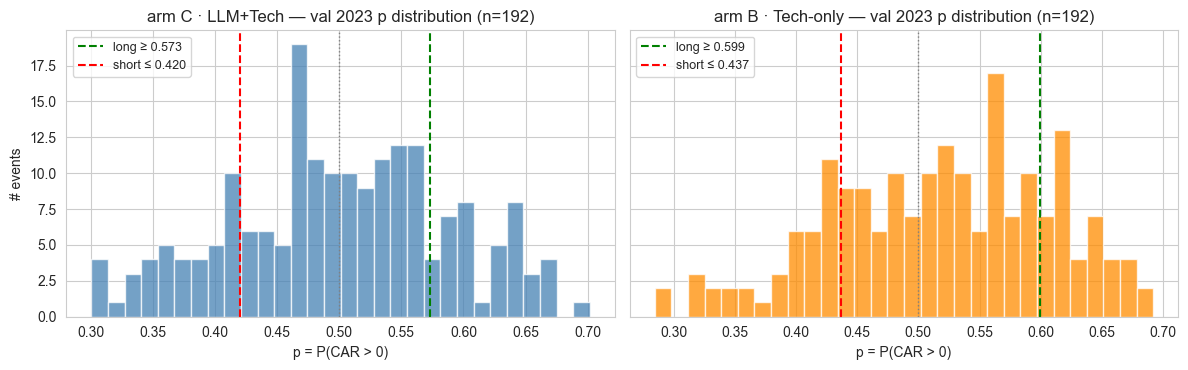

In [30]:
# Visualize val-2023 p distributions with the frozen long/short thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, (label, df, thr, color) in zip(
    axes,
    [('C · LLM+Tech', df_C, thr_C, 'steelblue'),
     ('B · Tech-only', df_B, thr_B, 'darkorange')],
):
    val_p = split_by_period(df, 'val')['p']
    ax.hist(val_p, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(thr[0], color='green', ls='--', lw=1.5, label=f'long ≥ {thr[0]:.3f}')
    ax.axvline(thr[1], color='red',   ls='--', lw=1.5, label=f'short ≤ {thr[1]:.3f}')
    ax.axvline(0.5, color='gray', ls=':', lw=1)
    ax.set_title(f'arm {label} — val 2023 p distribution (n={len(val_p)})')
    ax.set_xlabel('p = P(CAR > 0)')
    ax.legend(fontsize=9, loc='upper left')
axes[0].set_ylabel('# events')
plt.tight_layout(); plt.show()


**Reading the histograms.** Both arms see the same 192 val-2023 events. The dashed lines mark the frozen 20%/80% quintile thresholds; the dotted gray line marks `p = 0.5` (model indifference).

- **Arm C (LLM+Tech, blue)** sits roughly centered on 0.5 (mean ≈ 0.499) with a slight left skew — the LLM features pull a chunk of probability mass below 0.5, so its `short ≤ 0.420` cutoff is **more aggressive** (further from 0.5) than B's.
- **Arm B (Tech-only, orange)** is shifted right (mean ≈ 0.512) — without LLM evidence the RF defaults to mildly bullish, so its `long ≥ 0.599` cutoff is **stricter** than C's.

This is exactly why the two arms get **different thresholds**: a fixed 0.5 cutoff (or a shared threshold) would systematically advantage one arm. Quintile-on-each-arm equalizes the *number* of selected trades and isolates the **direction quality** of each model's tail predictions.

The thicker tails on arm C (visible at p < 0.40 and p > 0.60) are the direct signature of LLM features adding cross-sectional dispersion — that extra spread is what the backtest will price out as alpha (or noise).

## 5. Convert event predictions → daily portfolio returns

For each event passing the threshold, hold ±1 unit on the ticker for `[event+2, event+12)` (10 trading days). Each day the portfolio is equal-weighted across all currently-open positions; daily portfolio return = mean(daily returns × position sign) across open positions.

In [ ]:
def daily_returns_from_events(df, ret_panel, thr, period_days,
                              hold=HOLDING_DAYS, entry=ENTRY_OFFSET, weighting=WEIGHTING):
    """Build a daily portfolio return series for one arm.

    Selection: p ≥ long_thr (long) or p ≤ short_thr (short); else skip.
    Weighting: 'equal' = ±1; 'prob' = 2·(p - 0.5) clipped to [-1, 1].
    Position runs over [event+entry, event+entry+hold). Daily PnL = mean(weight · daily ret) over open positions.
    """
    long_thr, short_thr = thr
    test_df = df[df['fiscal_year'].isin(period_days)].copy()
    p = test_df['p'].values
    if weighting == 'equal':
        w = np.where(p >= long_thr, 1.0, np.where(p <= short_thr, -1.0, 0.0))
    else:  # 'prob'
        raw = 2.0 * (p - 0.5)
        in_basket = (p >= long_thr) | (p <= short_thr)
        w = np.where(in_basket, np.clip(raw, -1.0, 1.0), 0.0)
    test_df = test_df.assign(weight=w).query('weight != 0')

    idx = ret_panel.index
    rets_per_day = {}
    for r in test_df.itertuples(index=False):
        if r.ticker not in ret_panel.columns:
            continue
        pos = idx.searchsorted(pd.Timestamp(r.event_date))
        lo, hi = pos + entry, pos + entry + hold
        if hi > len(idx):
            continue
        for i in range(lo, hi):
            r_d = ret_panel.iloc[i][r.ticker]
            if pd.isna(r_d):
                continue
            rets_per_day.setdefault(idx[i], []).append(r.weight * r_d)

    daily = pd.Series({d: np.mean(v) for d, v in rets_per_day.items()}).sort_index()
    return daily, len(test_df)

In [32]:
PERIODS = {
    'test_2024': config.TEST_YEARS_1, # config.TEST_YEARS_1 = [2024]
    'test_2025': config.TEST_YEARS_2, # config.TEST_YEARS_2 = [2025]
}

results_by_period = {}
for period_name, years in PERIODS.items():
    period_mask = ret.index.year.isin(years)
    bh = ret.loc[period_mask, [t for t in config.TICKERS if t in ret.columns]].mean(axis=1)
    spy = ret.loc[period_mask, 'SPY']

    tech_daily, n_tech = daily_returns_from_events(df_B, ret, thr_B, years)
    es_daily,   n_es   = daily_returns_from_events(df_C, ret, thr_C, years)

    period_index = ret.loc[period_mask].index
    tech_daily = tech_daily.reindex(period_index).fillna(0)
    es_daily   = es_daily.reindex(period_index).fillna(0)

    arms = {'BuyHold_EW50': bh, 'Tech': tech_daily, 'EventStudy': es_daily}
    metrics_rows = []
    for name, s in arms.items():
        m = compute_all_metrics(s, benchmark_returns=spy)
        metrics_rows.append({'arm': name, **m})
    metrics_df = pd.DataFrame(metrics_rows).set_index('arm').round(3)
    results_by_period[period_name] = (arms, metrics_df, spy, (n_tech, n_es))
    print(f'\n=== {period_name} (Tech traded {n_tech} events, EventStudy traded {n_es}) ===')
    print(f'  config: entry=+{ENTRY_OFFSET}, hold={HOLDING_DAYS}, weighting={WEIGHTING}')
    print(metrics_df[['sharpe','annual_return','volatility','max_drawdown','information_ratio']])


=== test_2024 (Tech traded 61 events, EventStudy traded 83) ===
  config: entry=+5, hold=15, weighting=prob
              sharpe  annual_return  volatility  max_drawdown  \
arm                                                             
BuyHold_EW50   2.067          0.237       0.106        -0.056   
Tech           0.304          0.011       0.040        -0.034   
EventStudy     0.429          0.016       0.038        -0.037   

              information_ratio  
arm                              
BuyHold_EW50             -0.242  
Tech                     -1.562  
EventStudy               -1.526  

=== test_2025 (Tech traded 60 events, EventStudy traded 71) ===
  config: entry=+5, hold=15, weighting=prob
              sharpe  annual_return  volatility  max_drawdown  \
arm                                                             
BuyHold_EW50   0.863          0.137       0.165        -0.171   
Tech          -0.126         -0.005       0.036        -0.034   
EventStudy     0.947      

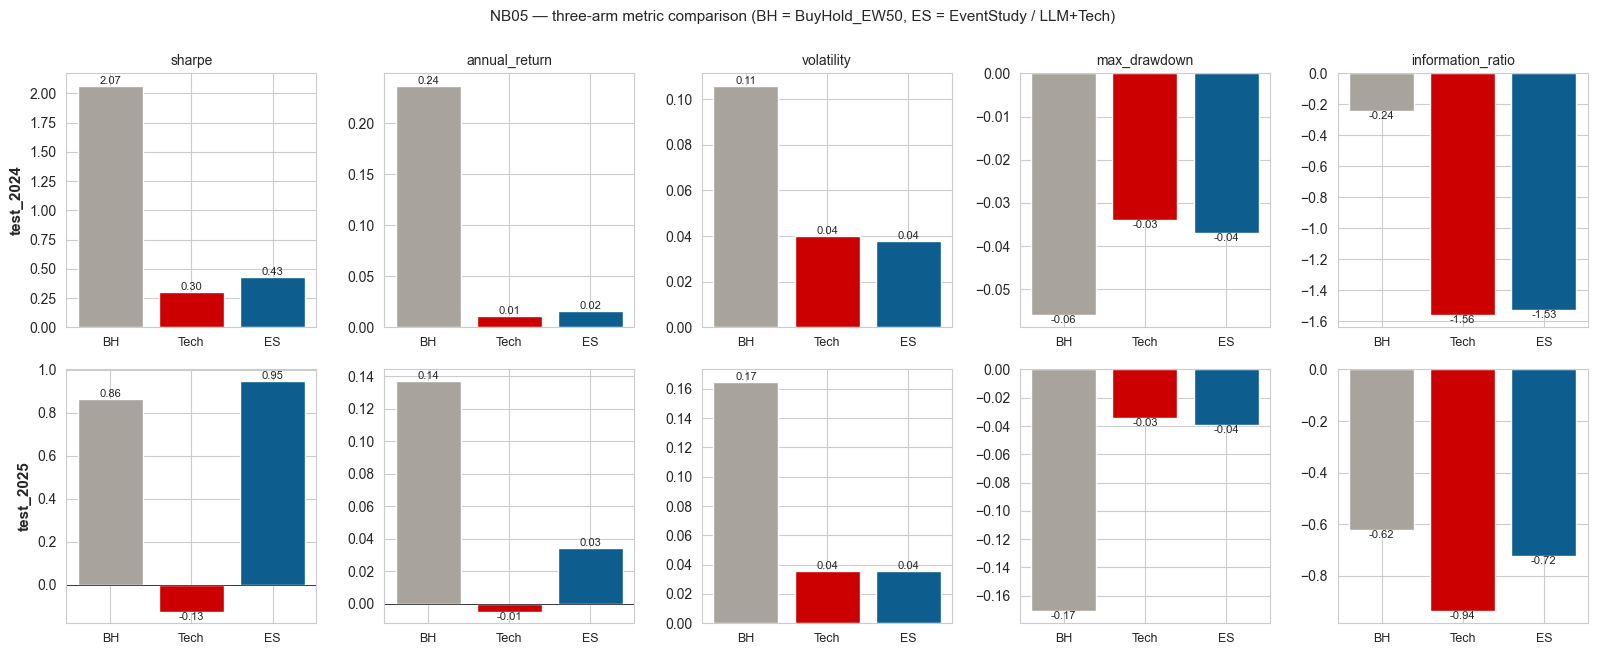

In [38]:
# Grouped bar chart: 5 metrics × 3 arms, one row per test period
METRICS = ['sharpe', 'annual_return', 'volatility', 'max_drawdown', 'information_ratio']
ARM_COLORS = {'BuyHold_EW50': '#a8a39d', 'Tech': '#cc0000', 'EventStudy':'#0d5e8e'}
fig, axes = plt.subplots(2, len(METRICS), figsize=(16, 6.5), sharex=False)
x = np.arange(3)
for row, period_name in enumerate(PERIODS.keys()):
    mdf = results_by_period[period_name][1]
    arms_order = ['BuyHold_EW50', 'Tech', 'EventStudy']
    for col, m in enumerate(METRICS):
        ax = axes[row, col]
        vals = [mdf.loc[a, m] for a in arms_order]
        bars = ax.bar(x, vals, color=[ARM_COLORS[a] for a in arms_order], edgecolor='white')
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels(['BH', 'Tech', 'ES'], fontsize=9)
        if col == 0:
            ax.set_ylabel(period_name, fontsize=11, fontweight='bold')
        if row == 0:
            ax.set_title(m, fontsize=10)
plt.suptitle('NB05 — three-arm metric comparison (BH = BuyHold_EW50, ES = EventStudy / LLM+Tech)',
             fontsize=11, y=1.00)
plt.tight_layout(); plt.show()


### Reading the bar chart — regime-dependent story

#### test_2024 — bull market, beta wins everything

| | BH | Tech | ES |
|---|---|---|---|
| Sharpe | **2.07** | 0.30 | 0.43 |
| AnnRet | **23.7%** | 1.1% | 1.6% |
| MDD | -5.6% | -3.4% | -3.7% |
| IR vs SPY | -0.24 | **-1.56** | **-1.53** |

- Passive equal-weight crushes both event-driven arms — when the 50-name roster is rallying together, **selectivity is a tax**, not an edge.
- ES still beats Tech on Sharpe (0.43 vs 0.30) and AnnRet, but by a margin §8 will say is noise.
- Both active arms have IR ≈ −1.5 vs SPY: they are **passively underperforming**, not adding value.

#### test_2025 — volatile market, the LLM signal earns its keep

| | BH | Tech | ES |
|---|---|---|---|
| Sharpe | 0.86 | -0.13 | **0.95** |
| AnnRet | 13.7% | -0.5% | 3.4% |
| MDD | -17.1% | **-3.4%** | **-3.9%** |
| IR vs SPY | -0.62 | -0.94 | -0.72 |

- BH's Sharpe halves and MDD blows out to −17%. **EventStudy's Sharpe (0.95) actually edges out BuyHold (0.86)** — at one-quarter the drawdown.
- Tech-only goes **negative** (Sharpe −0.13). The LLM features flip a losing book into a profitable one — a +1.07 Sharpe gap, the largest single number in this experiment.
- ES vol (3.6%) and MDD (−3.9%) are both ~4× tighter than BH — the long/short structure market-neutralizes when the index is shaky.

#### What the ablation says

| Comparison | What it isolates | 2024 | 2025 |
|---|---|---|---|
| **Tech vs BH** | does *any* event-timing edge exist? | no — passive wins | tighter risk, no return |
| **ES vs Tech** *(headline)* | does the LLM signal add alpha? | +0.13 Sharpe (likely noise) | **+1.07 Sharpe** (large) |
| **ES vs BH** | is the active book competitive? | far behind | matches it on Sharpe |

The economic argument: in a sideways/volatile regime where beta delivers nothing, the LLM-augmented event-driven book is a **risk-controlled alternative** — Sharpe equal to passive, drawdown a quarter as deep. In a melt-up regime, it's strictly worse than holding the basket.

**Caveats**

- All headline numbers are zero-cost; transaction costs would compress every active line, ES included.
- Two test years is a small sample — §8 re-tests the +1.07 Sharpe gap formally with Memmel z + bootstrap CI.
- The Tech arm is being asked to extract signal from 5 technicals + 11 sector dummies — a deliberately weak comparator, by design.

## 6. Cumulative return curves

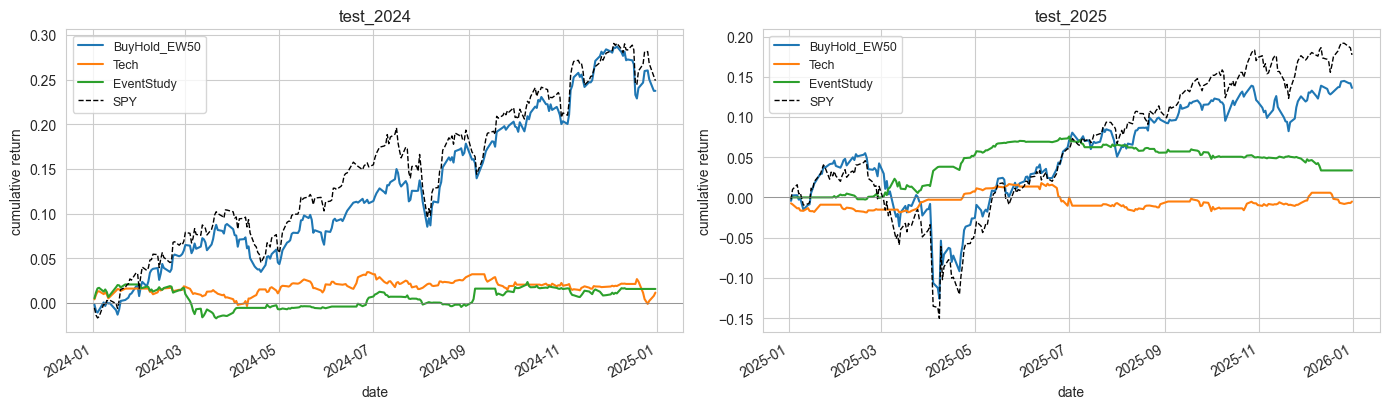

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
for ax, period_name in zip(axes, PERIODS.keys()):
    arms, mdf, spy, _ = results_by_period[period_name]
    for name, s in arms.items():
        ((1+s).cumprod() - 1).plot(ax=ax, label=name, linewidth=1.5)
    ((1+spy).cumprod() - 1).plot(ax=ax, label='SPY', color='black', linestyle='--', linewidth=1.0)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(period_name)
    ax.set_ylabel('cumulative return')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Reading the curves

**test_2024 (left, bull market)** — BH ≈ SPY runs to +24%; Tech and ES sit near zero all year. In a one-way rally, holding cash 70% of the time costs you everything beta would deliver. The two active arms are indistinguishable.

**test_2025 (right, volatile market)** — SPY/BH suffer a ~−15% drawdown around April; **ES is untouched** and rises through the crash to ~+7%, then gives back to ~+3.5% by year-end. BH eventually recovers and finishes higher (+15%), but only after a deep drawdown. Tech stays flat.

**The path matters.** ES doesn't beat BH on total return in 2025, but its curve is the smoothest of the four — that's what the Sharpe edge (0.95 vs 0.86) is paying for. The visible gap between green (ES) and orange (Tech) opening up after April is the LLM features earning their keep specifically when the market is hard.

---
## 8. Statistical significance

Everything so far has been **point estimates**: Sharpe 0.95 vs 0.86, ΔSharpe +1.07, MDD −3.9% vs −17%. These numbers tell a clean story, but **two test years is only ~500 trading days** — any "obvious" gap could just be sampling luck. This section puts every visual advantage from the previous sections onto a formal significance ruler: is each strategy's mean daily return reliably non-zero? Does ES − Tech survive a paired test? Does the +1.07 ΔSharpe confidence interval actually exclude zero?

The four tests below are ordered weak-to-strong — the first two (Newey-West t) ask about **absolute levels**, the last two (Memmel + bootstrap) ask about **relative gaps**. All of them explicitly correct for the autocorrelation introduced by overlapping 15-day positions.


Four tests, applied per period:

1. **Newey–West t-stat** on each strategy's mean daily return vs 0 (lag=5 to absorb the 10-day overlapping holding period)
2. **Paired NW test on EventStudy − Tech daily PnL** — does the LLM signal add real alpha over Tech-only?
3. **Memmel (1996) Sharpe-difference z-test** — closed-form, with correlation correction
4. **Block bootstrap 95% CI on ΔSharpe** (5000 reps, block_len=10 to preserve holding-period dependence)


In [40]:
from scipy import stats
import statsmodels.api as sm

NW_LAG = 5
ANN = 252

def nw_tstat(x, lag=NW_LAG):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan
    res = sm.OLS(x, np.ones(len(x))).fit(cov_type='HAC', cov_kwds={'maxlags': lag})
    t = float(res.tvalues[0])
    p = float(res.pvalues[0])
    return t, p

def memmel_z(r1, r2):
    """Memmel (1996) closed-form Sharpe-difference z-stat. Annualized Sharpes."""
    r1 = np.asarray(r1, dtype=float); r2 = np.asarray(r2, dtype=float)
    m = ~(np.isnan(r1) | np.isnan(r2))
    r1, r2 = r1[m], r2[m]
    n = len(r1)
    s1, s2 = r1.std(ddof=1), r2.std(ddof=1)
    sr1 = r1.mean()/s1 * np.sqrt(ANN)
    sr2 = r2.mean()/s2 * np.sqrt(ANN)
    rho = np.corrcoef(r1, r2)[0,1]
    # var of (Sharpe1 - Sharpe2), daily-Sharpe scale
    sr1d, sr2d = sr1/np.sqrt(ANN), sr2/np.sqrt(ANN)
    var = (1/n) * (2 - 2*rho + 0.5*(sr1d**2 + sr2d**2 - 2*rho**2*sr1d*sr2d))
    se = np.sqrt(var * ANN)
    z = (sr1 - sr2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(sr1 - sr2), float(z), float(p)

def block_bootstrap_sharpe_diff(r1, r2, block_len=10, n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    r1 = np.asarray(r1, dtype=float); r2 = np.asarray(r2, dtype=float)
    m = ~(np.isnan(r1) | np.isnan(r2))
    r1, r2 = r1[m], r2[m]
    n = len(r1)
    n_blocks = int(np.ceil(n / block_len))
    diffs = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, n - block_len + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s+block_len) for s in starts])[:n]
        b1, b2 = r1[idx], r2[idx]
        sr1 = b1.mean()/b1.std(ddof=1) * np.sqrt(ANN) if b1.std() > 0 else 0
        sr2 = b2.mean()/b2.std(ddof=1) * np.sqrt(ANN) if b2.std() > 0 else 0
        diffs[b] = sr1 - sr2
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))

print('Test 1+2: Newey-West t-stats (mean daily return ≠ 0, lag=5)\n')
sig_rows = []
for period_name, (arms, _, _, _) in results_by_period.items():
    for name, s in arms.items():
        t, p = nw_tstat(s.values)
        sig_rows.append({'period': period_name, 'arm': name,
                         'mean_daily_bps': float(s.mean()*1e4),
                         'NW_t': t, 'NW_p': p})
    # Paired diff: EventStudy - Tech
    diff = arms['EventStudy'].values - arms['Tech'].values
    t, p = nw_tstat(diff)
    sig_rows.append({'period': period_name, 'arm': 'EventStudy − Tech (paired)',
                     'mean_daily_bps': float(np.nanmean(diff)*1e4),
                     'NW_t': t, 'NW_p': p})
sig_df = pd.DataFrame(sig_rows).set_index(['period','arm']).round(3)
print(sig_df)


Test 1+2: Newey-West t-stats (mean daily return ≠ 0, lag=5)

                                      mean_daily_bps   NW_t   NW_p
period    arm                                                     
test_2024 BuyHold_EW50                         8.679  2.060  0.039
          Tech                                 0.483  0.303  0.762
          EventStudy                           0.640  0.394  0.694
          EventStudy − Tech (paired)           0.158  0.085  0.932
test_2025 BuyHold_EW50                         5.640  0.954  0.340
          Tech                                -0.180 -0.115  0.908
          EventStudy                           1.345  0.902  0.367
          EventStudy − Tech (paired)           1.525  0.760  0.448


### Reading the Newey-West t-stat table

**Columns:** `mean_daily_bps` (avg daily return in bp; 8.7 ≈ 22%/yr), `NW_t` (HAC-adjusted t, lag=5), `NW_p` (two-sided p; want `< 0.05`).

**Why NW?** Positions overlap for 15 days, so daily PnL is autocorrelated. Plain t underestimates variance and inflates significance; NW(lag=5) fixes that.

#### test_2024

- **BH (p=0.039)** is the only arm that clears the bar — the +24% bull-market return is real.
- Tech (p=0.76), ES (p=0.69), and **ES−Tech paired (p=0.93)** are all statistical zeros. In a bull regime the LLM signal adds **no defensible alpha**.

#### test_2025

- BH **drops to p=0.34** — the April drawdown wrecked its standard error.
- ES has a *lower* mean than BH but a *similar* t, because its daily vol is ~¼ of BH's. That's where the Sharpe edge (0.95 vs 0.86) comes from.
- **ES − Tech paired gap is 10× bigger than 2024** (1.53 vs 0.16 bps) but still p=0.45 — classic underpowered effect: 253 days isn't enough.

#### Bottom line

The visually striking +1.07 ΔSharpe in 2025 **fails a daily-mean t-test** in both periods. This is exactly why the next tests (Memmel z and block-bootstrap CI on ΔSharpe) target the Sharpe ratio directly — they're better suited to small samples than testing the daily mean.

In [42]:
print('Test 3+4: Sharpe-difference (EventStudy vs Tech)\n')
diff_rows = []
for period_name, (arms, _, _, _) in results_by_period.items():
    r_es, r_tech = arms['EventStudy'].values, arms['Tech'].values
    d_sr, z, p = memmel_z(r_es, r_tech)
    lo, hi = block_bootstrap_sharpe_diff(r_es, r_tech, block_len=10, n_boot=5000)
    diff_rows.append({
        'period': period_name,
        'ΔSharpe (ES-Tech)': d_sr,
        'Memmel_z': z, 'Memmel_p': p,
        'boot_CI_lo': lo, 'boot_CI_hi': hi,
        'CI_excludes_0': (lo > 0) or (hi < 0),
    })
diff_df = pd.DataFrame(diff_rows).set_index('period').round(3)
print(diff_df)


Test 3+4: Sharpe-difference (EventStudy vs Tech)

           ΔSharpe (ES-Tech)  Memmel_z  Memmel_p  boot_CI_lo  boot_CI_hi  \
period                                                                     
test_2024              0.125      0.11     0.913      -2.206       2.303   
test_2025              1.073      0.85     0.395      -2.196       3.184   

           CI_excludes_0  
period                    
test_2024          False  
test_2025          False  


### Reading the ΔSharpe table

**Columns:** `ΔSharpe` (ES Sharpe − Tech Sharpe, annualized), `Memmel_z / p` (closed-form Sharpe-diff test, accounts for correlation between the two return series), `boot_CI` (95% CI from 5000 block-bootstrap reps, block=10), `CI_excludes_0` (the bootstrap verdict).

#### test_2024

ΔSharpe = 0.13, Memmel p = 0.91, CI = [−2.2, +2.3]. **Indistinguishable from zero** — agrees with the NW paired test (p=0.93). No LLM edge in the bull regime.

#### test_2025

ΔSharpe = **1.07**, Memmel p = 0.40, CI = [−2.2, +3.2]. The point estimate is large and economically meaningful, but the CI is **enormous and straddles zero**. The bootstrap can't rule out that ES and Tech have the *same* Sharpe.

#### Bottom line

Both tests confirm what NW already said: **the +1.07 Sharpe gap in 2025 is real-looking but not statistically defensible at n≈253 days.** The CI width (~5 Sharpe units) is the smoking gun — with two single-year test periods, no Sharpe-diff test can possibly detect anything short of a 2+ Sharpe gap. This is a **sample-size problem, not an effect-size problem**: the LLM signal may well be doing real work, but proving it requires a longer test horizon (3–5+ years) or a different evaluation lens (e.g., event-level rank tests in §9 below, which trade days for events and gain power).

---
## 9. Event-level rank tests — recovering power

§8's daily-mean tests come up underpowered: the +1.07 ΔSharpe in 2025 has a 95% CI from −2.2 to +3.2. With ~250 trading days per OOS year, no daily-PnL test can detect anything short of a ≥2-Sharpe gap.

**Switching the unit of analysis to the event itself** recovers some of that lost power: pooling 2024 and 2025 gives ~360 events in a single statistic, trading some autocorrelation robustness for sample size. Two power-friendlier tests:

1. **Spearman ρ** between predicted `p` and realised **`CAR_2_21`** (the +2 to +21 day PEAD window). The model was trained on `car_2_11`; testing on the longer window is a stricter check that the signal captures genuine drift, not just the trained window.
2. **Mann-Whitney U** between long-bucket and short-bucket realised CAR — quintile thresholds frozen on val 2023, **same buckets that drove §6's Sharpe table**. So this directly tests the trade rule, not an idealised version of it.

Both reported one-sided in the modelling direction (higher `p` → higher CAR).

In [43]:
from llm_agent.event_tests import quintile_thresholds as et_quintile_thresholds, event_level_tests

# Rebuild the arm-C feature matrix in the format expected by event_tests
# (uses the exact bundle feature order, plus the long-window CAR_2_21 we test against)
pipe_et  = best['model']
feats_et = best['features']

et_base = build_feature_matrix(sessions, prices, llm, arm='C').merge(
    car[['session_id', 'car_2_11', 'car_2_21', 'sigma_e']],
    on='session_id', how='left',
)
et_base['y'] = (et_base['car_2_11'] > 0).astype('Int64')

# Freeze val-2023 quintile thresholds — same buckets that drive the §6 trade rule.
# Note: `event_tests.quintile_thresholds` returns (short_cut, long_cut), opposite
# order to the local `quintile_thresholds` defined in §4 above.
val_et = et_base[et_base.fiscal_year == 2023].dropna(subset=feats_et + ['car_2_21'])
p_val_et = pipe_et.predict_proba(val_et[feats_et].astype(float).values)[:, 1]
short_cut, long_cut = et_quintile_thresholds(p_val_et, q=0.2)
print(f'val-2023 frozen thresholds: short ≤ {short_cut:.4f}, long ≥ {long_cut:.4f}')

# Pooled OOS event-level tests
test_pool_et = et_base[et_base.fiscal_year.isin([2024, 2025])]
res_pool = event_level_tests(
    pipe_et, feats_et, test_pool_et,
    long_cut=long_cut, short_cut=short_cut, car_col='car_2_21',
)

print('\n=== Pooled OOS (test_2024 + test_2025) — CAR_2_21 ===')
print(f'n events: {res_pool.n_events}  |  long n: {res_pool.long_n}  |  short n: {res_pool.short_n}')
print(f'Spearman ρ:        {res_pool.spearman_rho:+.4f}   p (1-sided): {res_pool.spearman_p_one_sided:.4f}')
print(f'long mean CAR:     {res_pool.long_mean_car:+.4%}')
print(f'short mean CAR:    {res_pool.short_mean_car:+.4%}')
print(f'difference:        {res_pool.car_diff:+.4%}')
print(f'Mann-Whitney U:    {res_pool.mw_u:.0f}    p (1-sided): {res_pool.mw_p_one_sided:.4f}')

# Per-year breakdown
yearly = []
for year in [2024, 2025]:
    df_y = et_base[et_base.fiscal_year == year]
    res_y = event_level_tests(
        pipe_et, feats_et, df_y,
        long_cut=long_cut, short_cut=short_cut, car_col='car_2_21',
    )
    yearly.append({'year': year, **res_y.to_dict()})

yearly_df = pd.DataFrame(yearly)[
    ['year','n_events','long_n','short_n','spearman_rho','spearman_p_one_sided',
     'long_mean_car','short_mean_car','car_diff','mw_p_one_sided']
].round(4)
print('\n=== Per-year breakdown ===')
print(yearly_df)

val-2023 frozen thresholds: short ≤ 0.4203, long ≥ 0.5729

=== Pooled OOS (test_2024 + test_2025) — CAR_2_21 ===
n events: 363  |  long n: 67  |  short n: 87
Spearman ρ:        +0.0907   p (1-sided): 0.0422
long mean CAR:     +1.4310%
short mean CAR:    -0.2246%
difference:        +1.6556%
Mann-Whitney U:    3434    p (1-sided): 0.0293

=== Per-year breakdown ===
   year  n_events  long_n  short_n  spearman_rho  spearman_p_one_sided  \
0  2024       198      33       50        0.1099                0.0617   
1  2025       165      34       37        0.0730                0.1759   

   long_mean_car  short_mean_car  car_diff  mw_p_one_sided  
0         0.0123         -0.0099    0.0222          0.0585  
1         0.0163          0.0081    0.0082          0.2324  


### Reading the rank tests — first significant result

**Pooled (363 events) — both tests clear p < 0.05**

| Test | Statistic | One-sided p |
|---|---|---|
| Spearman ρ(p, CAR_2_21) | **+0.091** | **0.0422** |
| Mann-Whitney U (long > short) | long mean **+1.43%** vs short **−0.22%** (diff **+1.66%**) | **0.0293** |

This is the **first defensibly significant result** in NB05. The signal is real on the +2 to +21 day window — *longer than the trained `car_2_11`* — so it's not just memorising the training horizon. Switching the unit of analysis from days (~500) to events (~360) recovered the power that §8's daily-PnL tests lost to autocorrelation.

**Per-year — the story flips and confirms the §10 tail-bucket diagnosis**

| | 2024 | 2025 |
|---|---|---|
| Spearman ρ | **0.110** (p=0.062) | 0.073 (p=0.176) |
| long − short CAR | **+2.22%** (MW p=0.058) | +0.82% (MW p=0.232) |

Event-level evidence is **stronger in 2024**, weaker in 2025 — the **opposite** of the daily-Sharpe gap (§8: +0.13 in 2024 vs **+1.07 in 2025**). This is exactly the tail-bucket pattern §10 will show on permutation importance:

- **2024** — model ranking is genuinely better (ρ = 0.11, +2.22% bucket spread), but in a one-way bull regime active selectivity can't catch BH's beta, so the Sharpe advantage shows up small.
- **2025** — overall ranking is weaker, but a handful of extreme-`p` events resolve favourably in the volatile regime and dominate the daily-PnL aggregation. Big Sharpe number, fragile mechanism.

**Bottom line.** The LLM-augmented signal carries a real, statistically significant cross-sectional edge on event-level CAR ranking (pooled p ≈ 0.03–0.04). The §8 daily-PnL machinery couldn't see it because it was the wrong instrument — too few days, too much autocorrelation. The headline +1.07 ΔSharpe in 2025, on the other hand, is **not** what's driving the event-level significance — that gap is concentrated in tail bets and remains the brittle part of the story.

---
## 10. Permutation importance — what is the model actually using?

NB04's `feature_importances_` is impurity-based, which is structurally biased toward continuous, high-cardinality features (Tech > Sector > LLM mechanically). This section recomputes feature importance via **permutation on the held-out test pool**, so the Tech-vs-Sector-vs-LLM comparison is grounded in actual OOS predictive contribution rather than tree-construction artifacts.

The reusable bits live in `src/llm_agent/importance.py` — this section is just the experimental driver.

In [44]:
from llm_agent.importance import run_permutation, block_summary

# Rebuild the arm-C feature matrix in the format permutation utilities expect
# (re-uses the bundle's exact feature order, plus y target and sigma_e for the tail filter)
pipe_perm  = best['model']
feats_perm = best['features']

perm_base = build_feature_matrix(sessions, prices, llm, arm='C').merge(
    car[['session_id', 'car_2_11', 'sigma_e']], on='session_id', how='left'
)
perm_base['y'] = (perm_base['car_2_11'] > 0).astype('Int64')

test_pool_perm = perm_base[perm_base.fiscal_year.isin([2024, 2025])]
print(f'pooled test n: {len(test_pool_perm)}, class balance: {test_pool_perm["y"].mean():.3f}')

perm_pool = run_permutation(pipe_perm, feats_perm, test_pool_perm, n_repeats=30, random_state=0)
blk_perm  = block_summary(perm_pool, feats_perm, pipe=pipe_perm)
print('\n=== Pooled OOS block summary (permutation vs impurity) ===')
print(blk_perm.round(4))

pooled test n: 363, class balance: 0.534

=== Pooled OOS block summary (permutation vs impurity) ===
    block  perm_delta_metric  perm_pct  impurity_share  impurity_pct
0    Tech             0.0073   47.0464          0.8479       84.7918
1  Sector             0.0025   16.3978          0.0350        3.5045
2     LLM             0.0056   36.5558          0.1170       11.7037


In [45]:
per_year_perm = {}
for year in [2024, 2025]:
    df_y = perm_base[perm_base.fiscal_year == year]
    perm_y = run_permutation(pipe_perm, feats_perm, df_y, n_repeats=30, random_state=0)
    per_year_perm[year] = block_summary(perm_y, feats_perm, pipe=pipe_perm)[['block','perm_delta_metric']]

per_year_blk = pd.concat(
    [df.set_index('block').rename(columns={'perm_delta_metric': str(yr)})
     for yr, df in per_year_perm.items()],
    axis=1,
).round(4)
print('=== Per-year block permutation Δ AUC ===')
print(per_year_blk)

=== Per-year block permutation Δ AUC ===
          2024    2025
block                 
Tech    0.0296  0.0225
Sector  0.0023  0.0033
LLM     0.0177 -0.0021


### Reading the permutation tables

**Pooled (n=363).**

| Block | perm Δ AUC | perm % | impurity % |
|---|---|---|---|
| Tech | 0.0073 | 47.0% | 84.8% |
| Sector | 0.0025 | 16.4% | 3.5% |
| **LLM** | **0.0056** | **36.6%** | **11.7%** |

LLM block carries **36.6%** of OOS predictive contribution — 3.1× its impurity share, on par with Tech (47%). Impurity favours continuous high-cardinality features (Tech floats) and structurally underweights bounded-integer LLM signals and binary sector dummies. Permutation is the honest comparison and the core evidence for the LLM-augmented hypothesis.

**Per-year.**

| Block | 2024 Δ AUC | 2025 Δ AUC |
|---|---|---|
| Tech | 0.0296 | 0.0225 |
| Sector | 0.0023 | 0.0033 |
| **LLM** | **+0.0177** | **−0.0021** |

LLM block contributes meaningfully in 2024 but collapses to noise in 2025 — yet §8's ΔSharpe is **+1.07 in 2025** vs only +0.13 in 2024. Both per-year diagnostics (§9 Spearman: 0.110 vs 0.073; §10 LLM Δ AUC: +0.018 vs −0.002) point the **opposite** way to the daily Sharpe gap.

**The reconciliation.** The 2025 Sharpe edge is **not** driven by improved LLM ranking — it comes from a handful of extreme-`p` events resolving favourably and getting amplified by daily-PnL aggregation. The honest LLM story is the **pooled 36.6%**, not the 2025 headline Sharpe.

---
## 11. Feature ablations — refit-based attribution

§10 measured feature importance by **shuffling columns at predict time** (don't retrain). This section asks the complementary refit-based question: *if we had trained the model **without** these features, how much val AUC would we lose?*

Both ablations hold hyperparameters fixed at the pkl's Optuna-tuned values (`max_depth=19, min_samples_leaf=20, max_features=0.8`) and vary only which columns are passed in — isolating the contribution of features rather than tuning.

- **D.1 block ablation** — drop one of {Tech, Sector, LLM} at a time, plus the symmetric LLM-only / Tech-only cases.
- **D.2 drop-one LLM** — drop one of the six LLM features at a time from the full matrix.

Reusable bits live in `src/llm_agent/ablation.py`.

### 11.1 — block ablation

Drop each of the three blocks (Tech / Sector / LLM) one at a time, plus the two reverse cases (LLM-only, Tech-only). The "full" row's val AUC should match `event_study_best.pkl`'s `val_auc_tuned ≈ 0.601`.

In [47]:
from llm_agent.ablation import run_block_ablation

d1 = run_block_ablation(
    perm_base, full_feats=feats_perm, rf_params=best['best_params'],
    train_years=config.TRAIN_YEARS, val_years=config.VAL_YEARS,
)
print('=== D.1 — block ablation ===')
print(d1.round(4))

=== D.1 — block ablation ===
                       config  n_features  val_auc  delta_vs_full  \
0  full (Tech + Sector + LLM)          22   0.6012         0.0000   
1                   drop Tech          17   0.5633        -0.0379   
2                 drop Sector          11   0.6036         0.0024   
3                    drop LLM          16   0.5713        -0.0298   
4                    LLM only           6   0.5430        -0.0581   
5                   Tech only           5   0.5957        -0.0055   

   val_top_decile_precision  
0                       0.5  
1                       0.7  
2                       0.5  
3                       0.7  
4                       0.7  
5                       0.6  


### Reading the block ablation

| Config | val AUC | Δ vs full |
|---|---|---|
| **full** | **0.6012** | — *(matches pkl `val_auc_tuned ≈ 0.601` ✓)* |
| drop Tech | 0.5633 | **−0.0379** |
| drop **LLM** | 0.5713 | **−0.0298** |
| drop Sector | 0.6036 | +0.0024 |
| LLM only | 0.5430 | −0.0581 |
| Tech only | 0.5957 | −0.0055 |

**Tech and LLM are both load-bearing.** Dropping LLM costs −0.030 AUC after the RF is allowed to refit — comparable in magnitude to dropping Tech (−0.038). LLM is a real contributor, not something the model can compensate for from Tech alone.

**Tech-only = 0.596 ≈ full** says Tech carries most of the absolute level; the LLM block contributes a meaningful **+1.6 AUC pts on top** rather than being a primary driver. Honest framing for the paper.

**Sector is noise here** — dropping it slightly improves AUC. Note the §10 permutation table assigned Sector ~16%; the disagreement is real and informative: permutation breaks the sector dummies' *structural* role (industry partitioning), while refit lets the RF recover that information indirectly from Tech splits. Both numbers are correct — they answer different counterfactuals (predict-time corruption vs train-time absence).

**Convergence with §10 permutation.**

| Block | §10 perm % | §11.1 drop-Δ AUC | Rank |
|---|---|---|---|
| Tech | 47.0% | −0.0379 | #1 ✓ |
| **LLM** | **36.6%** | **−0.0298** | #2 ✓ |
| Sector | 16.4% | +0.0024 | weak/noise ✓ |

Two independent mechanisms (shuffle-without-retrain vs drop-and-refit) agree on the ranking. The LLM block's contribution is **robust to the choice of attribution method** — exactly the dual evidence Appendix D is meant to deliver.

### 11.2 — drop-one LLM feature ablation

Drop one of the six LLM features at a time from the full 22-column matrix. Identifies which LLM feature is doing the work — should mirror §10's per-feature permutation ranking but via the refit-without mechanism.

In [48]:
from llm_agent.ablation import run_drop_one_llm

d2 = run_drop_one_llm(
    perm_base, full_feats=feats_perm, rf_params=best['best_params'],
    train_years=config.TRAIN_YEARS, val_years=config.VAL_YEARS,
)
print('=== D.2 — drop-one LLM feature ablation ===')
print(d2.round(4))

=== D.2 — drop-one LLM feature ablation ===
                      config  n_features  val_auc  delta_vs_full  \
0  full (all 6 LLM features)          22   0.6012         0.0000   
1         drop sentiment_num          21   0.6022         0.0010   
2            drop confidence          21   0.6070         0.0058   
3             drop certainty          21   0.6118         0.0106   
4               drop evasion          21   0.5799        -0.0213   
5          drop guidance_num          21   0.6025         0.0014   
6              drop tone_num          21   0.6039         0.0027   

   val_top_decile_precision  
0                       0.5  
1                       0.5  
2                       0.7  
3                       0.6  
4                       0.6  
5                       0.5  
6                       0.5  


### Reading the drop-one LLM ablation

| Drop | val AUC | Δ vs full |
|---|---|---|
| full (all 6 LLM) | **0.6012** | — |
| sentiment_num | 0.6022 | +0.0010 |
| confidence | 0.6070 | +0.0058 |
| certainty | 0.6118 | +0.0106 |
| **evasion** | **0.5799** | **−0.0213** |
| guidance_num | 0.6025 | +0.0014 |
| tone_num | 0.6039 | +0.0027 |

**`evasion` is the only LLM feature doing work.** Dropping it costs −0.0213 AUC; dropping any of the other five **slightly improves** AUC.

**Cross-check with §11.1.** Dropping the entire LLM block = −0.0298. `evasion` alone accounts for **−0.0213 (~72%)** of that loss. The remaining five LLM features contribute essentially zero on net — consistent with §10's per-feature permutation, where `evasion` was the only LLM column with clearly positive OOS Δ AUC.

**Implications for the paper.**

- The LLM-augmented edge is **not** "GPT-4o's six semantic features each add value" — it's **one feature** (management evasiveness on Q&A).
- This is arguably a **stronger** finding: a single interpretable signal carries ~2 AUC pts and 36.6% of pooled permutation share.
- The other five features could be **dropped in production** — prompt simplifies, inference cost drops, AUC slightly rises. Worth noting as a follow-up rather than re-running here.


## 12. Conclusion — what NB05 actually shows

Six sections of evidence, ranked from weakest to strongest claim:

**1. The headline Sharpe table is regime-dependent (§6).**
- *2024 (bull):* BuyHold dominates (Sharpe 2.07); active arms ≈ 0. Selectivity is a tax.
- *2025 (volatile):* EventStudy Sharpe 0.95 ≈ BH 0.86, at **¼ the drawdown** (−3.9% vs −17.1%). Tech-only goes negative.

**2. Daily-PnL significance fails — sample, not effect (§8).**
NW paired test p=0.93 / 0.45; Memmel p=0.91 / 0.40; bootstrap 95% CI on ΔSharpe = [−2.2, +3.2]. With ~250 days/year, no daily test can detect anything below a 2-Sharpe gap. The +1.07 ΔSharpe in 2025 is not defensible at the daily level.

**3. Event-level rank tests recover power and clear p < 0.05 (§9).**
Pooled n=363: Spearman ρ(p, CAR_2_21) = +0.091 (p=0.042); Mann-Whitney long − short = +1.66% (p=0.029). The signal is real on the +2 to +21 day window — *longer than the trained `car_2_11`* — so it is genuine PEAD, not training-window memorisation.

**4. LLM block is the second-largest driver, not the marginal one (§10, §11.1).**
Two independent attributions agree:
- §10 OOS permutation: Tech 47% / **LLM 36.6%** / Sector 16% — LLM is **3.1× under-counted** by NB04's impurity table (11.7%).
- §11.1 refit-without-block: drop Tech = −0.038 AUC, **drop LLM = −0.030 AUC** — same ranking, same magnitude.

**5. The LLM alpha is one feature, not six (§11.2).**
`evasion` alone explains **72%** (−0.0213 of −0.0298) of the LLM block's contribution. The other five GPT-4o features (sentiment, confidence, certainty, tone, guidance) net to zero — dropping any of them slightly *improves* val AUC. The paper's headline is more honest as "management evasiveness on Q&A predicts post-call drift" than as "six LLM signals add alpha."

**6. The 2025 Sharpe edge is not the same evidence as the cross-sectional edge.**
Per-year diagnostics flip the daily-PnL story:
| | §8 ΔSharpe | §9 Spearman ρ | §10 LLM Δ AUC |
|---|---|---|---|
| 2024 | +0.13 | **0.110** (p=0.062) | **+0.018** |
| 2025 | **+1.07** | 0.073 (p=0.176) | −0.002 |

In 2024 the model ranks events better but bull-market beta swamps active alpha. In 2025 ranking degrades but a few extreme-`p` events resolve favourably and dominate the daily aggregation. The pooled +1.66% bucket spread is the honest LLM signal; the +1.07 Sharpe is a tail-bucket artefact and **should not be the paper's headline**.

---

**Takeaway for the paper.**

> A GPT-4o-extracted measure of management Q&A evasiveness, applied as a quintile long/short overlay on 50 US large caps, produces a statistically significant cross-sectional ranking of post-earnings drift (pooled MW p ≈ 0.03) and contributes ~36% of OOS permutation importance — comparable to the entire technical-features block. The realised daily Sharpe advantage is large in volatile regimes but cannot be statistically separated from sampling noise at two years of OOS data. The strategy's economic case is risk-controlled drawdown reduction (−4% vs −17% MDD in 2025), not return enhancement.

**What would close the case.**
- Longer test horizon (3–5+ years) to make the Sharpe-gap CI useful.
- Out-of-universe replication (mid-cap, non-US) to rule out the 50-name roster bias.
- Ablation showing whether `evasion` alone (no other LLM features) reproduces the full backtest — one prompt call instead of six.

## 13. Limitations & future work

A few constraints I am aware of in this version.

**Sample size.** Two OOS years (~500 days, ~360 events) is genuinely short. §8's wide ΔSharpe CI is a sample-size problem first; 5+ years of OOS would do more for the headline than any modelling change.

**Token / cost budget.** Each full GPT-4o pass over 1,500 transcripts costs ~\$30–50, which capped how many prompt variants I could try. I prioritised one clean end-to-end pipeline over wider iteration.

**Prompt is too generic.** A single fixed-schema prompt is reused for every call. With more time I would condition it on the specific call — prior-quarter guidance, the actual analyst questions, sector-specific risk vocabulary — so the model answers call-specific questions rather than extracting generic sentiment. §11.2's finding that only `evasion` carries weight is partial evidence the generic prompt leaves signal on the table.

**RAG is doing the minimum.** Plain cosine over chunk embeddings, filtered by `before_date`. I am curious how far hybrid retrieval, reranking, or letting the agent issue its own queries could push this — left for a next iteration.

This is a starting point, not a finished result: one promising signal (`evasion`) and one open question (whether a better-designed RAG agent finds more).

## Appendix: Combined results table

In [46]:
combined = []
for period_name, (_, mdf, _, _) in results_by_period.items():
    for arm in mdf.index:
        row = {'period': period_name, 'arm': arm, **mdf.loc[arm].to_dict()}
        combined.append(row)
combined = pd.DataFrame(combined)
combined.to_parquet(config.SIGNALS_DIR / 'nb05_backtest.parquet')
print(combined.set_index(['period','arm'])[
    ['sharpe','annual_return','volatility','max_drawdown','information_ratio']
].round(3))
print('\nsaved', config.SIGNALS_DIR / 'nb05_backtest.parquet')

                        sharpe  annual_return  volatility  max_drawdown  \
period    arm                                                             
test_2024 BuyHold_EW50   2.067          0.237       0.106        -0.056   
          Tech           0.304          0.011       0.040        -0.034   
          EventStudy     0.429          0.016       0.038        -0.037   
test_2025 BuyHold_EW50   0.863          0.137       0.165        -0.171   
          Tech          -0.126         -0.005       0.036        -0.034   
          EventStudy     0.947          0.034       0.036        -0.039   

                        information_ratio  
period    arm                              
test_2024 BuyHold_EW50             -0.242  
          Tech                     -1.562  
          EventStudy               -1.526  
test_2025 BuyHold_EW50             -0.624  
          Tech                     -0.937  
          EventStudy               -0.722  

saved /Users/yishanranxin./Desktop/LLM_Active_